In [1]:
import pandas as pd
import numpy as np
import re
import zipfile

zip_path = "../00_Data/original_kaggle_data_download_archive.zip"

with zipfile.ZipFile(zip_path) as z:
    print(z.namelist())  # See what files are inside
    f1 = pd.read_csv(z.open("1429_1.csv"))
    f2 = pd.read_csv(z.open("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv"))
    f3 = pd.read_csv(z.open("Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv"))

['1429_1.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products.csv', 'Datafiniti_Amazon_Consumer_Reviews_of_Amazon_Products_May19.csv']


C:\Users\Antonio\AppData\Local\Temp\ipykernel_4024\4084535014.py:10: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  f1 = pd.read_csv(z.open("1429_1.csv"))


In [2]:
"""
Data preparation for the Automated Customer Reviews project.
Merges the 3 raw Datafiniti/Amazon review exports, deduplicates, cleans the
corrupted `name` field, maps star ratings to sentiment classes, and writes
a single clean dataset for downstream modeling.
"""

OUT_PATH = "clean_reviews.csv"

print(f"f1 {f1.shape}, f2 {f2.shape}, f3 {f3.shape}")

# ---- Keep only columns relevant to NLP tasks ----
keep_cols = ["id", "name", "asins", "brand", "categories", "primaryCategories",
             "reviews.date", "reviews.rating", "reviews.text", "reviews.title"]

for df in (f1, f2, f3):
    for c in keep_cols:
        if c not in df.columns:
            df[c] = np.nan

merged = pd.concat([f1[keep_cols], f2[keep_cols], f3[keep_cols]], ignore_index=True)
print(f"merged raw {merged.shape}")

# ---- Deduplicate: same product + review text + rating ----
merged = merged.dropna(subset=["reviews.text", "reviews.rating"])
merged = merged.drop_duplicates(subset=["id", "reviews.text", "reviews.rating"])
print(f"after dedup {merged.shape}")
print(f"unique product IDs: {merged['id'].nunique()}")
print(f"unique product names (raw): {merged['name'].nunique()}")

# ---- Fix corrupted `name` field (two names concatenated together) ----
def clean_name(name):
    if pd.isna(name):
        return name
    name = str(name)
    # Datafiniti corruption pattern: "Name A,,,,Name B" or names glued with commas
    # Keep first product-name segment (before a run of 2+ commas, or before an
    # obvious second product name starting after a comma cluster)
    parts = re.split(r",{2,}", name)
    first = parts[0].strip()
    return first

merged["name_clean"] = merged["name"].apply(clean_name)
print(f"unique product names (cleaned): {merged['name_clean'].nunique()}")



f1 (34660, 21), f2 (5000, 24), f3 (28332, 24)
merged raw (67992, 10)
after dedup (59743, 10)
unique product IDs: 89
unique product names (raw): 119
unique product names (cleaned): 109


In [3]:
# ---- Sentiment mapping ----
def map_sentiment(rating):
    if pd.isna(rating):
        return np.nan
    rating = int(rating)
    if rating <= 2:
        return "negative"
    elif rating == 3:
        return "neutral"
    else:
        return "positive"

merged["sentiment"] = merged["reviews.rating"].apply(map_sentiment)
merged = merged.dropna(subset=["sentiment"])

# ---- Combine title + text as model input ----
merged["review_text_full"] = (
    merged["reviews.title"].fillna("") + ". " + merged["reviews.text"].fillna("")
).str.strip()
merged = merged[merged["review_text_full"].str.len() > 3]

print("\nFinal dataset:")
print(f"  rows: {len(merged)}")
print(f"  unique product IDs: {merged['id'].nunique()}")
print(f"  unique cleaned product names: {merged['name_clean'].nunique()}")
print("\nSentiment class distribution:")
print(merged["sentiment"].value_counts())
print(merged["sentiment"].value_counts(normalize=True).round(3))

merged.to_csv(OUT_PATH, index=False)
print(f"\nSaved -> {OUT_PATH}")


Final dataset:
  rows: 59743
  unique product IDs: 89
  unique cleaned product names: 109

Sentiment class distribution:
sentiment
positive    54841
neutral      2588
negative     2314
Name: count, dtype: int64
sentiment
positive    0.918
neutral     0.043
negative    0.039
Name: proportion, dtype: float64

Saved -> clean_reviews.csv



<hr>

## Create a unique product table

In [10]:
# ---- Clustering only the unique product names ----

unique_products = merged["name_clean"].drop_duplicates()

print(len(unique_products))

110


## Convert to TF-IDF vectors

In [13]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2)
)
unique_products = pd.Series(unique_products).dropna().astype(str)
X = vectorizer.fit_transform(unique_products)

## Determine the optimal number of clusters

In [14]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np


K = range(2, 11)

inertia = []
silhouette = []

for k in K:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = kmeans.fit_predict(X)

    # Elbow Method
    inertia.append(kmeans.inertia_)

    # Silhouette Score
    silhouette.append(
        silhouette_score(X, labels)
    )

## Elbow Method

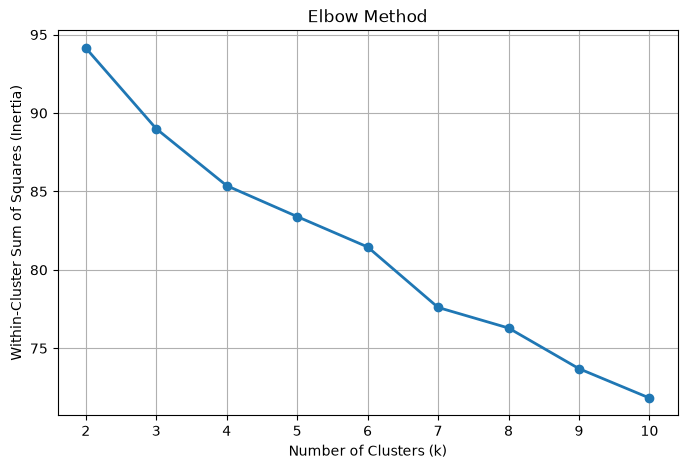

In [15]:
plt.figure(figsize=(8,5))

plt.plot(
    K,
    inertia,
    marker='o',
    linewidth=2
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Within-Cluster Sum of Squares (Inertia)")
plt.grid(True)

plt.show()  # ---- Look for the point where the curve starts to flatten ("the elbow").

## Silhouette Score

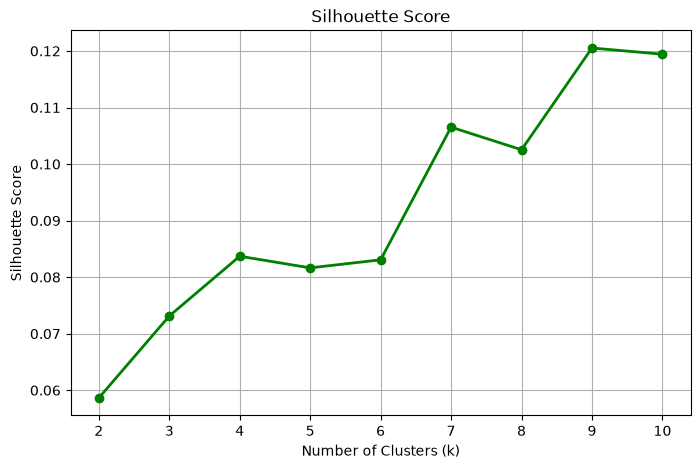

In [16]:
# --- The highest Silhouette Score generally indicates the best separation between clusters.

plt.figure(figsize=(8,5))

plt.plot(
    K,
    silhouette,
    marker='o',
    linewidth=2,
    color='green'
)

plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

# Table Results

In [17]:
import pandas as pd

results = pd.DataFrame({
    "Clusters": list(K),
    "Inertia": inertia,
    "Silhouette Score": silhouette
})

display(results)

,Clusters,Inertia,Silhouette Score
0,2,94.147330,0.058628
1,3,88.998625,0.073120
2,4,85.367373,0.083700
3,5,83.397259,0.081640
4,6,81.460168,0.083065
5,7,77.603479,0.106523
6,8,76.291114,0.102529
7,9,73.698947,0.120524
8,10,71.828884,0.119423


## Automatically select the best k

In [18]:
best_k = K[np.argmax(silhouette)]

print(f"Best number of clusters according to Silhouette Score: {best_k}")

Best number of clusters according to Silhouette Score: 9


## Run KMeans

In [19]:
kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=20
)

labels = kmeans.fit_predict(X)

products = pd.DataFrame({
    "product": unique_products,
    "cluster": labels
})

## Interpret each cluster

In [20]:
for c in sorted(products.cluster.unique()):

    print("="*60)

    print(f"Cluster {c}")

    display(
        products.loc[
            products.cluster==c
        ].sort_values("product")
    )

Cluster 0


,product,cluster
59051,All-New Kindle Oasis E-reader - 7 High-Resolut...,0
65531,All-New Kindle Oasis E-reader - 7 High-Resolut...,0
62365,All-New Kindle Oasis E-reader - 7 High-Resolut...,0
14446,Kindle Oasis E-reader with Leather Charging Co...,0
39422,Kindle Oasis E-reader with Leather Charging Co...,0
2814,Kindle Oasis E-reader with Leather Charging Co...,0
62359,Kindle Oasis E-reader with Leather Charging Co...,0
20987,"Kindle Paperwhite E-reader - White, 6 High-Res...",0
52544,"Kindle Voyage E-reader, 6 High-Resolution Disp...",0
20390,"Kindle Voyage E-reader, 6 High-Resolution Disp...",0


Cluster 1


,product,cluster
25033,Amazon - Amazon Tap Portable Bluetooth and Wi-...,1
21164,"Amazon - Fire 16GB (5th Gen, 2015 Release) - B...",1
24891,Amazon Fire Hd 6 Standing Protective Case(4th ...,1
21025,Amazon Fire Hd 8 8in Tablet 16gb Black B018szt...,1
65523,Amazon Fire TV Gaming Edition Streaming Media ...,1
35601,Amazon Fire TV with 4K Ultra HD and Alexa Voic...,1
25352,Amazon Fire Tv,1
2881,Amazon Kindle Lighted Leather Cover,1
17214,Amazon Kindle Paperwhite - eBook reader - 4 GB...,1
15526,Amazon Kindle Touch Leather Case (4th Generati...,1


Cluster 2


...

,product,cluster
57438,"All-New Fire 7 Tablet with Alexa, 7"" Display, ...",4
59062,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",4
59079,"All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...",4
58920,"Amazon Fire HD 8 with Alexa (8"" HD Display Tab...",4
65549,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",4
14478,"Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...",4
63868,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...",4
3051,"Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...",4
39369,"Fire HD 8 Tablet with Alexa, 8"" HD Display, 32...",4
61457,"Fire Tablet with Alexa, 7 Display, 16 GB, Blue...",4


Cluster 5


,product,cluster
53046,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
36279,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
53157,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
36293,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
2905,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5
38290,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",5
39461,"All-New Fire HD 8 Tablet, 8"" HD Display, Wi-Fi...",5
3266,"All-New Kindle E-reader - Black, 6 Glare-Free ...",5
52495,"All-New Kindle E-reader - Black, 6"" Glare-Free...",5


Cluster 6


,product,cluster
53040,All-new Echo (2nd Generation) with improved so...,6
35605,Amazon - Echo Plus w/ Built-In Hub - Silver,6
51881,Amazon Echo (1st Generationcertified) Color:Wh...,6
52528,Amazon Echo (2nd Generation) Smart Assistant O...,6
48009,Amazon Echo Show - Black,6
34756,Amazon Echo Show Alexa-enabled Bluetooth Speak...,6
21017,Amazon Echo and Fire TV Power Adapter,6
48007,Amazon Echo ‚Äì White,6
53037,Certified Refurbished Amazon Echo,6
24851,Echo (Black),6


<hr>

## Product Category Clustering

In [24]:
# ============================================================
# STEP 1: Create a dictionary to map cluster IDs to names
# ============================================================

cluster_names = {
    0: "E-Readers",
    1: "Others",
    2: "Tablets for Kids",
    3: "Chargers & Adapters",
    4: "Tablets with Alexa",
    5: "Tablets",
    6: "Smart Assistants"
}

# ============================================================
# STEP 2: Add descriptive names to the products lookup table
# ============================================================
"""
products["cluster_name"] = products["cluster"].map(cluster_names)

# Check the result
display(products.head())
"""
# ============================================================
# STEP 3: Merge the cluster information back into the full dataset
# ============================================================

products = pd.DataFrame({
    "name_clean": unique_products,
    "cluster": labels
})

products["cluster_name"] = products["cluster"].map(cluster_names)

merged = merged.merge(
    products[["name_clean", "cluster", "cluster_name"]],
    on="name_clean",
    how="left"
)

""""
merged = merged.merge(
    products[
        [
            "name_clean",
            "cluster",
            "cluster_name"
        ]
    ],
    on="name_clean",
    how="left"
)
"""
# ============================================================
# STEP 4: Verify the merge
# ============================================================

print("Merged dataset shape:", merged.shape)

display(
    merged[
        [
            "name_clean",
            "cluster",
            "cluster_name"
        ]
    ].head(15)
)

# ============================================================
# STEP 5: Number of products per cluster
# ============================================================

cluster_summary = (
    merged
    .groupby(["cluster", "cluster_name"])
    .size()
    .reset_index(name="Number of Products")
    .sort_values("cluster")
)

display(cluster_summary)

# ============================================================
# STEP 6: Display sample products from each cluster
# ============================================================

for cluster_id in sorted(cluster_names.keys()):

    print("=" * 70)
    print(f"Cluster {cluster_id}: {cluster_names[cluster_id]}")
    print("=" * 70)

    display(
        merged.loc[
            merged["cluster"] == cluster_id,
            "name_clean"
        ]
        .drop_duplicates()
        .sort_values()
        .reset_index(drop=True)
    )

Merged dataset shape: (59743, 15)


,name_clean,cluster,cluster_name
0,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
1,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
3,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
4,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
5,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
6,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
7,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
8,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets
9,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",5.0,Tablets


,cluster,cluster_name,Number of Products
0,0.0,E-Readers,849
1,1.0,Others,18360
2,2.0,Tablets for Kids,5366
3,3.0,Chargers & Adapters,354
4,4.0,Tablets with Alexa,4628
5,5.0,Tablets,18641
6,6.0,Smart Assistants,4786


Cluster 0: E-Readers


0    All-New Kindle Oasis E-reader - 7 High-Resolut...
1    All-New Kindle Oasis E-reader - 7 High-Resolut...
2    All-New Kindle Oasis E-reader - 7 High-Resolut...
3    Kindle Oasis E-reader with Leather Charging Co...
4    Kindle Oasis E-reader with Leather Charging Co...
5    Kindle Oasis E-reader with Leather Charging Co...
6    Kindle Oasis E-reader with Leather Charging Co...
7    Kindle Paperwhite E-reader - White, 6 High-Res...
8    Kindle Voyage E-reader, 6 High-Resolution Disp...
9    Kindle Voyage E-reader, 6 High-Resolution Disp...
Name: name_clean, dtype: str

...

0     All-New Fire 7 Tablet with Alexa, 7" Display, ...
1     All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...
2     All-New Fire HD 8 Tablet with Alexa, 8 HD Disp...
3     Amazon Fire HD 8 with Alexa (8" HD Display Tab...
4     Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...
5     Fire HD 8 Tablet with Alexa, 8 HD Display, 16 ...
6     Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...
7     Fire HD 8 Tablet with Alexa, 8 HD Display, 32 ...
8     Fire HD 8 Tablet with Alexa, 8" HD Display, 32...
9     Fire Tablet with Alexa, 7 Display, 16 GB, Blue...
10    Fire Tablet with Alexa, 7 Display, 16 GB, Mage...
11    Fire Tablet with Alexa, 7" Display, 16 GB, Mag...
Name: name_clean, dtype: str

Cluster 5: Tablets


0     All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
1     All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
2     All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
3     All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
4     All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
5     All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...
6     All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...
7     All-New Fire HD 8 Tablet, 8" HD Display, Wi-Fi...
8     All-New Kindle E-reader - Black, 6 Glare-Free ...
9     All-New Kindle E-reader - Black, 6" Glare-Free...
10    Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Specia...
11    Fire HD 10 Tablet, 10.1 HD Display, Wi-Fi, 16 ...
12    Fire Tablet, 7 Display, Wi-Fi, 16 GB - Include...
13    Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...
14    Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...
15    Kindle E-reader - White, 6 Glare-Free Touchscr...
Name: name_clean, dtype: str

Cluster 6: Smart Assistants


0     All-new Echo (2nd Generation) with improved so...
1           Amazon - Echo Plus w/ Built-In Hub - Silver
2     Amazon Echo (1st Generationcertified) Color:Wh...
3     Amazon Echo (2nd Generation) Smart Assistant O...
4                              Amazon Echo Show - Black
5     Amazon Echo Show Alexa-enabled Bluetooth Speak...
6                 Amazon Echo and Fire TV Power Adapter
7                                 Amazon Echo ‚Äì White
8                     Certified Refurbished Amazon Echo
9                                          Echo (Black)
10                                         Echo (White)
11                       Echo Dot (Previous generation)
12                           Echo Spot Pair Kit (Black)
Name: name_clean, dtype: str